# Cluster Profiling and Interpretation

## Overview

Finding clusters is the beginning, not the end. Cluster profiling — describing what makes each cluster distinct — is essential for translating statistical groupings into scientifically meaningful conclusions.

**Profiling workflow:**

1. **Summarise** feature means/medians and SDs per cluster
2. **Visualise** feature distributions within clusters (heatmap, violin, radar)
3. **Test** which features differ significantly between clusters (ANOVA, Kruskal-Wallis)
4. **Rank** features by discriminative power (effect size, variable importance)
5. **Name** clusters using domain knowledge
6. **Check** stability by examining uncertain/boundary observations

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(cluster)
library(patchwork)
library(pheatmap)      # annotated heatmaps
library(rstatix)       # kruskal_test(), dunn_test()
library(ggpubr)        # stat_compare_means()

set.seed(42)

# ── Simulate ecological sites + run k-means ───────────────────────────────────
n_per <- 90
prof_data <- bind_rows(
  tibble(nitrate=rnorm(n_per,2,0.6),  water_qual=rnorm(n_per,8,0.7),
         phosphorus=rnorm(n_per,0.3,0.1), turbidity=rnorm(n_per,3,0.9),
         dissolved_O2=rnorm(n_per,9.5,0.5), conductivity=rnorm(n_per,120,15),
         true_group="reference"),
  tibble(nitrate=rnorm(n_per,5,0.7),  water_qual=rnorm(n_per,5.5,0.8),
         phosphorus=rnorm(n_per,0.7,0.15), turbidity=rnorm(n_per,8,1.2),
         dissolved_O2=rnorm(n_per,7.5,0.7), conductivity=rnorm(n_per,200,25),
         true_group="restored"),
  tibble(nitrate=rnorm(n_per,9,0.9),  water_qual=rnorm(n_per,2.5,0.8),
         phosphorus=rnorm(n_per,1.6,0.25), turbidity=rnorm(n_per,18,2.5),
         dissolved_O2=rnorm(n_per,5.0,0.9), conductivity=rnorm(n_per,350,40),
         true_group="degraded")
)

feat_cols <- c("nitrate","water_qual","phosphorus","turbidity",
               "dissolved_O2","conductivity")
X_sc <- scale(prof_data[,feat_cols])

km_fit <- kmeans(X_sc, centers=3, nstart=25, iter.max=100)
prof_data <- prof_data %>% mutate(cluster=factor(km_fit$cluster))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'patchwork' was built under R version 4.4.3"
Warning message:
"package 'pheatmap' was built under R version

---

## Cluster Summary Statistics

# A tibble: 3 × 14
  cluster     n nitrate_mean nitrate_sd water_qual_mean water_qual_sd
  <fct>   <int>        <dbl>      <dbl>           <dbl>         <dbl>
1 1          90         9.03       0.89            2.52          0.79
2 2          90         2.03       0.63            7.93          0.65
3 3          90         5.02       0.69            5.35          0.75
# ℹ 8 more variables: phosphorus_mean <dbl>, phosphorus_sd <dbl>,
#   turbidity_mean <dbl>, turbidity_sd <dbl>, dissolved_O2_mean <dbl>,
#   dissolved_O2_sd <dbl>, conductivity_mean <dbl>, conductivity_sd <dbl>


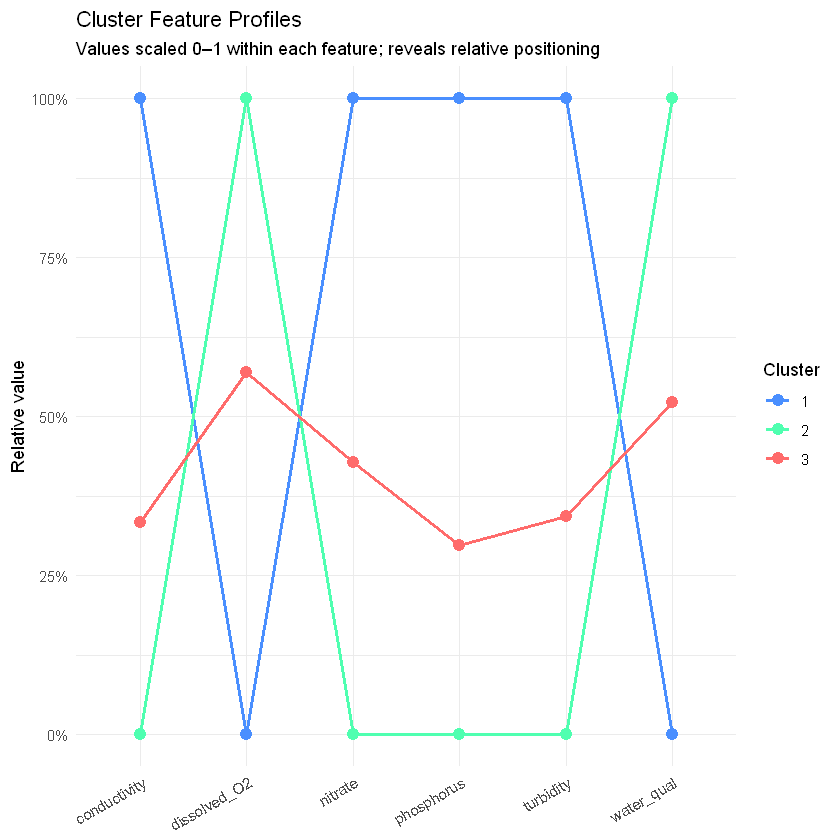

In [2]:
# ── Mean ± SD per feature per cluster ────────────────────────────────────────
cluster_summary <- prof_data %>%
  group_by(cluster) %>%
  summarise(
    n = n(),
    across(all_of(feat_cols),
           list(mean=~round(mean(.x),2), sd=~round(sd(.x),2)),
           .names="{.col}_{.fn}")
  )
print(cluster_summary)

# ── Grand mean standardised profile (radar data) ─────────────────────────────
# Standardise to [0,1] for each feature across clusters
profile_df <- prof_data %>%
  group_by(cluster) %>%
  summarise(across(all_of(feat_cols), mean), .groups="drop") %>%
  mutate(across(all_of(feat_cols),
                ~(.x - min(.x)) / (max(.x) - min(.x)))) %>%
  pivot_longer(-cluster, names_to="feature", values_to="value")

ggplot(profile_df, aes(x=feature, y=value, color=cluster, group=cluster)) +
  geom_line(linewidth=1) +
  geom_point(size=3) +
  scale_color_manual(values=c("#4a8fff","#4fffb0","#ff6b6b")) +
  scale_y_continuous(limits=c(0,1), labels=scales::percent) +
  labs(title="Cluster Feature Profiles",
       subtitle="Values scaled 0–1 within each feature; reveals relative positioning",
       x=NULL, y="Relative value", color="Cluster") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=30, hjust=1))

---

## Cluster Heatmap

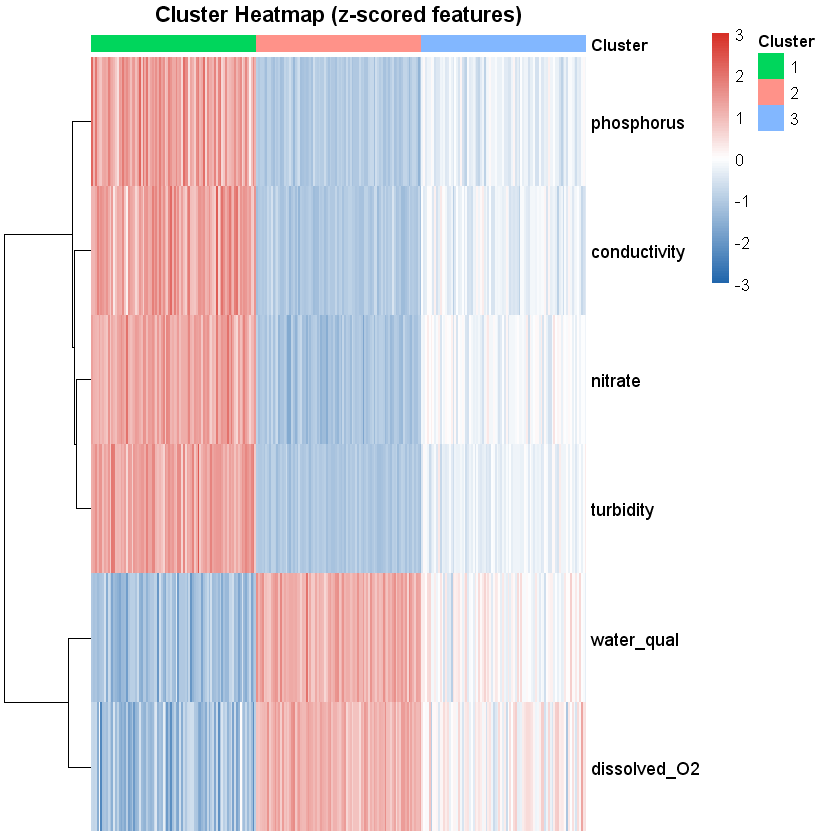

In [6]:
hm_mat <- X_sc[order(km_fit$cluster), ]
rownames(hm_mat) <- seq_len(nrow(hm_mat))  # set explicit rownames

row_ann <- data.frame(
  Cluster = factor(sort(km_fit$cluster))
)
rownames(row_ann) <- seq_len(nrow(hm_mat))  # match exactly

hm_t <- t(hm_mat)
colnames(hm_t) <- seq_len(ncol(hm_t))       # set explicit colnames

p <- pheatmap::pheatmap(
  hm_t,
  annotation_col = row_ann,
  cluster_cols   = FALSE,
  cluster_rows   = TRUE,
  show_colnames  = FALSE,
  color          = colorRampPalette(c("#2166ac", "white", "#d73027"))(100),
  breaks         = seq(-3, 3, length.out = 101),
  fontsize_row   = 11,
  main           = "Cluster Heatmap (z-scored features)"
)
print(p)

---

## Testing Feature Differences Between Clusters

# A tibble: 6 × 4
  feature      statistic p_value p_adj
  <chr>            <dbl>   <dbl> <dbl>
1 nitrate           239.       0     0
2 water_qual        238.       0     0
3 phosphorus        236.       0     0
4 turbidity         239.       0     0
5 dissolved_O2      231.       0     0
6 conductivity      237.       0     0


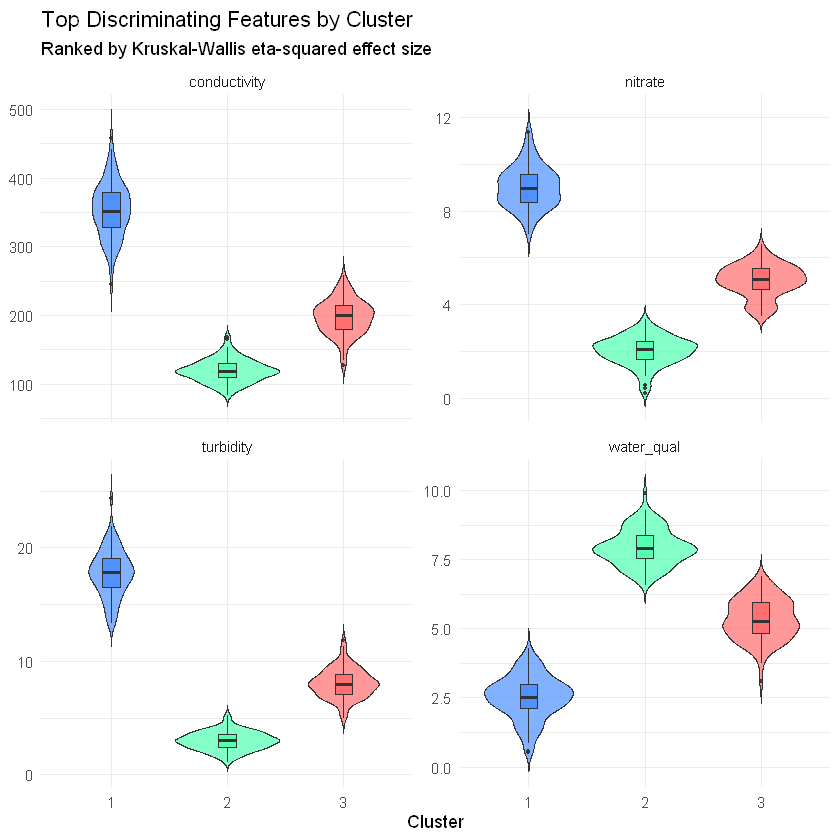

In [7]:
# Kruskal-Wallis: non-parametric test for differences across ≥3 groups
# Use when normality within clusters is uncertain
kw_results <- map_dfr(feat_cols, function(feat) {
  formula_str <- as.formula(paste(feat, "~ cluster"))
  kw <- rstatix::kruskal_test(prof_data, formula_str)
  tibble(
    feature  = feat,
    statistic = round(kw$statistic, 2),
    p_value   = round(kw$p, 4),
    p_adj     = round(p.adjust(kw$p, method="BH"), 4)
  )
}) %>% arrange(p_adj)

print(kw_results)

# Effect size: eta-squared from Kruskal-Wallis
# H / (n-1) ≈ eta-squared
kw_results <- kw_results %>%
  mutate(eta2 = round(statistic / (nrow(prof_data) - 1), 3))

# Violin plots for top discriminating features
top_feats <- kw_results %>% slice_max(eta2, n=4) %>% pull(feature)

prof_data %>%
  select(cluster, all_of(top_feats)) %>%
  pivot_longer(-cluster, names_to="feature", values_to="value") %>%
  ggplot(aes(x=cluster, y=value, fill=cluster)) +
  geom_violin(alpha=0.7, trim=FALSE) +
  geom_boxplot(width=0.15, alpha=0.9, outlier.size=0.8) +
  scale_fill_manual(values=c("#4a8fff","#4fffb0","#ff6b6b"), guide="none") +
  facet_wrap(~feature, scales="free_y", ncol=2) +
  labs(title="Top Discriminating Features by Cluster",
       subtitle="Ranked by Kruskal-Wallis eta-squared effect size",
       x="Cluster", y=NULL) +
  theme_minimal()

---

## Naming Clusters and Examining Boundary Cases

In [8]:
# ── Assign interpretive names based on profile ────────────────────────────────
# After examining the heatmap and summary: identify which cluster is which
centroid_profiles <- prof_data %>%
  group_by(cluster) %>%
  summarise(across(all_of(feat_cols), mean))

# Name based on nitrate level (key discriminating feature)
# In practice: use domain knowledge to name clusters meaningfully
cluster_names <- centroid_profiles %>%
  mutate(name = case_when(
    nitrate == min(nitrate) ~ "High quality (low N, high DO)",
    nitrate == max(nitrate) ~ "Degraded (high N, low DO)",
    TRUE                    ~ "Intermediate"
  )) %>%
  select(cluster, name)
print(cluster_names)

# ── Silhouette-based boundary identification ──────────────────────────────────
sil_obj <- cluster::silhouette(km_fit$cluster, dist(X_sc))

boundary_obs <- prof_data %>%
  mutate(
    sil_width   = sil_obj[,3],
    is_boundary = sil_width < 0.1   # near boundary or misassigned
  )

cat(sprintf("\nBoundary observations (silhouette < 0.1): %d (%.1f%%)\n",
            sum(boundary_obs$is_boundary),
            mean(boundary_obs$is_boundary)*100))

# These observations are genuinely ambiguous — report them separately
# or examine them for data quality issues
boundary_obs %>%
  filter(is_boundary) %>%
  select(cluster, all_of(feat_cols[1:4]), sil_width) %>%
  head(10)

# A tibble: 3 × 2
  cluster name                         
  <fct>   <chr>                        
1 1       Degraded (high N, low DO)    
2 2       High quality (low N, high DO)
3 3       Intermediate                 

Boundary observations (silhouette < 0.1): 0 (0.0%)


cluster,nitrate,water_qual,phosphorus,turbidity,sil_width
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


---

## Common Pitfalls

**1. Naming clusters before examining their profiles**  
Cluster labels are arbitrary integers. Always examine centroid profiles, heatmaps, and discriminating features before assigning interpretive names. Naming based on pre-existing expectations rather than the actual data produces circular reasoning.

**2. Testing every feature for differences without multiple comparison correction**  
Running separate Kruskal-Wallis tests for each of p features inflates the false discovery rate. Apply Benjamini-Hochberg correction (`p.adjust(p, method="BH")`) and focus interpretation on features with both statistical significance and meaningful effect sizes.

**3. Reporting cluster means without measuring within-cluster variability**  
A cluster with mean nitrate = 5.0 and SD = 3.0 is not meaningfully different from a cluster with mean = 4.5 and SD = 0.3. Always report standard deviations or interquartile ranges alongside means, and use violin plots rather than bar charts to show the full distribution.

**4. Not examining boundary observations**  
Observations with near-zero or negative silhouette widths are genuinely ambiguous — they could plausibly belong to two or more clusters. These should be reported as uncertain assignments, not treated as confidently classified. They may represent transitional ecological states, mixed-condition sites, or measurement error.

**5. Presenting cluster results without a stability check**  
Before investing in cluster interpretation and naming, verify that the cluster structure is stable by rerunning the analysis on bootstrap subsamples (e.g. 80% of the data, 100 times) and computing the mean ARI between bootstrap solutions. If mean ARI < 0.6, the clustering is unstable and interpretation should be cautious.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*